 # Odds Ratios

Dengue federated analysis workshop.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ISARICResearch/Dissemination/blob/main/workshops/federated%20analytics/FederatedAnalysis_Project/notebooks/03_odds_ratios.ipynb)

## Introduction

Odds ratios are a statistical measure used to evaluate how strongly a variable is associated with a specific outcome. In epidemiology, they are usually obtained by fitting a logistic regression model, where each odds ratio is calculated as the exponential of the corresponding model coefficient. They help identify risk factors during an outbreak, by showing which variables are linked to higher or lower odds of the outcome.

This notebook walks through the full process of calculating and comparing odds ratios using the workshop's dummy dengue dataset.

## Objective

Compare the odds ratios obtained with the centralized and federated approaches, to evaluate whether they match and identify where they diverge. The workshop uses a dummy dengue dataset from 5 health institutions, focusing on patients with severe dengue.

## Table of Contents

```
1. Setup
    1.1. Environment detection
    1.2. Install dependencies
    1.3. Get project files
    1.4. Imports
    1.5. Load data
2. Data Preparation
    2.1. Select patients with severe dengue
    2.2. Drop unused columns
    2.3. Drop rows with missing key values
    2.4. Impute missing values
    2.5. Distribution analysis
    2.6. Encode categorical values to numeric
    2.7. Feature scaling
3. Considerations
4. Centralized Approach
    4.1. Separate outcome and predictors
    4.2. Define the univariate model function
    4.3. Centralized results
    4.4. Forest plot
    4.5. Interpreting the results
5. Federated Approach
    5.1. Split the data by institution
    5.2. Per-site results
    5.3. Unstable per-site results
    5.4. Aggregated calculations
6. Comparison
    6.1. Comparison table
    6.2. Forest plot
    6.3. Interpreting the results
7. Conclusions
```

## 1. Setup

Prepare everything the notebook needs before starting the analysis.

### 1.1. Environment detection

Check whether this notebook is running on Google Colab or on a local computer.

In [1]:
import sys

# True on Google Colab, False on a local computer
IN_COLAB = "google.colab" in sys.modules

### 1.2. Install dependencies

Install any extra packages this notebook needs. This step only runs on Google Colab. On a local computer, the packages are already installed.

In [2]:
# if IN_COLAB:
#     %pip install -q <package>

### 1.3. Get project files

Get the project's data and code. On Google Colab, only the project's folder is downloaded first from the repository where it's published; on a local computer, they're already available next to this notebook.

In [3]:
from pathlib import Path

# Repository the project is downloaded from on Google Colab, and the project's folder inside it
REPO_URL, PROJECT_PATH = "https://github.com/ISARICResearch/Dissemination.git", "workshops/federated analytics/FederatedAnalysis_Project"
REPO_NAME = Path(REPO_URL).stem

if IN_COLAB:
    # Download only this project's folder, not the whole repository
    project_dir = Path(REPO_NAME) / PROJECT_PATH
    if not project_dir.exists():
        !git clone --depth 1 --filter=blob:none --sparse {REPO_URL}
        !git -C {REPO_NAME} sparse-checkout set "{PROJECT_PATH}"
else:
    # This notebook already lives inside the project
    project_dir = Path("..")

# Make the project's own code importable (e.g. `analysis_lib`)
sys.path.insert(0, str(project_dir))

data_dir = project_dir / "data"
data_file = data_dir / "dummy_data.parquet"
dictionary_file = data_dir / "dummy_data_dictionary.json"

### 1.4. Imports

Load the Python libraries used in this notebook.

In [4]:
# Standard library
import json

# Third-party
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

# Project
from analysis_lib.odds_ratios import (
    find_separated_predictors,
    format_comparison_table,
    format_odds_ratio_table,
    plot_distributions_by_outcome,
    plot_forest,
    pool_odds_ratios,
)
from analysis_lib.preprocessing import drop_columns_by_category, encode_yes_no, fillna_by_category

### 1.5. Load data

Read the example data.

In [5]:
# Load the full example dataset
df = pd.read_parquet(data_file)

# Load the data dictionary that describes each column
with open(dictionary_file, encoding="utf-8") as f:
    data_dictionary = json.load(f)

## 2. Data Preparation

Prepare the dataset for the odds ratio analysis: select patients with severe dengue, keep only the relevant columns, remove rows that can't be used and fill in missing values, and encode every column as a number so it can be used in a logistic regression.

### 2.1. Select patients with severe dengue

This workshop focuses on the subset of patients whose `final_classification` is `"Severe dengue"`. The goal is to identify, within this group, how the variables in the dataset are associated with death.

After this step, the dataset has 571 patients.

In [6]:
# Keep only patients with severe dengue
df = df[df["final_classification"] == "Severe dengue"]

### 2.2. Drop unused columns

Remove the columns not needed for the odds ratio analysis: identification (`record_id`) and dates, plus `final_classification` (the same for every patient after 2.1) and `hospitalized` (kept out of the predictor set).

In [7]:
# Drop identification and date columns, not used in the odds ratio analysis
df = drop_columns_by_category(df, data_dictionary, categories_to_drop=["Identification", "Date"])

# Drop columns not used as predictors
df = df.drop(columns=["final_classification", "hospitalized"])

### 2.3. Drop rows with missing key values

Remove records that can't be used in the analysis: with no data at all, with no known outcome, or with no known institution.

This dataset doesn't have any, but the check is included as a standard data-cleaning step.

In [8]:
df = df.dropna(how="all")
df = df.dropna(subset=["outcome", "institution"])

### 2.4. Impute missing values

Fill in the remaining missing values before modelling, since logistic regression can't handle them.

- Exam and symptom columns: a missing value means the exam wasn't performed or the symptom wasn't recorded, so it's filled as `"No"`.
- `sex`: a missing value is filled as `"Unknown"` (this dataset has none, this step is included for completeness).

In [9]:
# A missing exam or symptom means it wasn't performed/observed, treated the same as "No"
df = fillna_by_category(df, data_dictionary, categories=["Exam", "Symptom"], fill_value="No")

# No missing sex values exist in this dataset; included for completeness
df["sex"] = df["sex"].fillna("Unknown")

### 2.5. Distribution analysis

Before fitting any model, check how each candidate predictor is distributed regarding the outcome. A predictor that never varies, or whose values almost perfectly line up with one outcome or the other, can't produce a meaningful odds ratio: the model will still run, but the resulting estimate is unstable or meaningless, even though nothing raises an error.

In [ ]:
# The outcome column and every other column except institution (kept for the federated split, not used as a predictor)
outcome = "outcome"
predictors = [column for column in df.columns if column not in (outcome, "institution")]

plot_distributions_by_outcome(df, outcome=outcome, predictors=predictors, event_value="Dead")

**What the plots show:**

- `fever` never varies: every record has `fever = "Yes"`, so it carries no information about the outcome at all.
- `tissue_sample_taken` and the 7 organ-specific tissue samples (`liver_sample`, `spleen_sample`, `lung_sample`, `brain_sample`, `myocardium_sample`, `bone_marrow_sample`, `kidney_sample`) are almost always taken post-mortem: only 2 of the 57 patients with `tissue_sample_taken = "Yes"` are alive. Their values almost perfectly line up with the outcome, which makes their odds ratios implausibly high (in the hundreds, with very wide confidence intervals) instead of reflecting a real, stable association.
- `petechiae` almost never varies: only 1 patient has `petechiae = "Yes"`, and they survived, so its odds ratio collapses to 0 with an uninformative confidence interval.

These 10 columns are dropped before modelling. The remaining predictors don't show these patterns (both outcome categories are well represented for every value of each predictor), so they are kept.

In [11]:
# Drop predictors that don't vary, or whose values almost perfectly line up with the outcome
unstable_predictors = [
    "fever",
    "tissue_sample_taken",
    "liver_sample",
    "spleen_sample",
    "lung_sample",
    "brain_sample",
    "myocardium_sample",
    "bone_marrow_sample",
    "kidney_sample",
    "petechiae",
]
df = df.drop(columns=unstable_predictors)

### 2.6. Encode categorical values to numeric

Convert every categorical column into numbers, as required by the logistic regression model.

- Exam and symptom columns: `"Yes"`/`"No"` → `1`/`0`.
- `sex`: `"Female"`/`"Male"` → `0`/`1`.
- `outcome`: `"Alive"`/`"Dead"` → `0`/`1`, so an odds ratio above 1 means higher odds of death.

In [12]:
# Encode every exam/symptom column from "Yes"/"No" to 1/0
df = encode_yes_no(df, data_dictionary, categories=["Exam", "Symptom"])

# Encode sex and the outcome; "Dead" is coded as 1 so odds ratios above 1 mean higher odds of death
df["sex"] = df["sex"].map({"Female": 0, "Male": 1}).astype(int)
df["outcome"] = df["outcome"].map({"Alive": 0, "Dead": 1}).astype(int)

### 2.7. Feature scaling

This notebook fits the logistic regression with `statsmodels`, using its GLM class with a Binomial family and its default fitting method (IRLS), the standard maximum-likelihood approach for this kind of model. These defaults are kept as-is throughout the notebook.

A natural question at this point: shouldn't `age` be scaled down to the same 0-1 range as the exam/symptom predictors it now sits alongside?

It isn't necessary here. IRLS is mathematically equivalent to Newton's method for a model like this one, and Newton's method is invariant to rescaling a variable: it converges to the exact same fitted odds ratios regardless of the units a predictor is measured in. This differs from gradient-descent-based solvers, and from Lasso/Ridge-regularized models, which penalize coefficients based on their size and do require scaling to treat every predictor fairly. This is relevant for `05_prediction.ipynb`, where those methods are more likely to come into play.

Leaving `age` unscaled also keeps its odds ratio directly interpretable as "the change in odds of death per additional year of age", rather than "per standard deviation of age", a less intuitive unit for this workshop's audience.

## 3. Considerations

A few modelling decisions apply to both the centralized and federated approaches, explained here once instead of repeating them in every section:

- **The model is fit on the whole dataset, with no train/test split.** This is an interpretive/explanatory analysis, not a predictive one: the goal is to describe how each variable is associated with the outcome in this data, not to estimate how well the model would predict outcomes for new, unseen patients. Train/test splits and cross-validation exist specifically to measure that second thing (predictive generalization), so they don't add anything here, and the usual concern about overfitting doesn't apply either, since no performance on unseen data is being claimed. Predictive and interpretive/explanatory modelling are different tasks with different goals, and good practices for one don't always carry over to the other; `05_prediction.ipynb`, being predictive, is where a train/test split belongs instead.
- **`statsmodels` is used instead of `scikit-learn`.** `statsmodels` reports odds ratios, confidence intervals and p-values directly, which is what this kind of explanatory analysis needs; `scikit-learn` is built around prediction accuracy instead.
- **Each variable is modelled univariately (alone), not all together in one multivariate model.** A multivariate model is only recommended when there are enough outcome events relative to the number of predictors. Here there are 97 deaths for 22 candidate predictors (about 4-5 events per variable), well below the ~10 events per variable usually recommended, so a single multivariate model with all of them would produce unstable, unreliable estimates.

## 4. Centralized Approach

Compute the odds ratios over the whole dataset, as if all institutions shared their data directly.

### 4.1. Separate outcome and predictors

Identify the outcome column and the columns to model as predictors. `institution` is excluded: it isn't a predictor here, it's kept for splitting the data by site in the federated approach.

In [13]:
outcome = "outcome"

# Every column except the outcome and institution
predictors = [column for column in df.columns if column not in (outcome, "institution")]

### 4.2. Define the univariate model function

Fit a separate logistic regression for each predictor (variable), one at a time (see section 3 for why), and collect the following:

- **Odds ratio**: how the odds of death change with the predictor. For a Yes/No predictor, it compares the odds of death of patients with "Yes" against those with "No"; for `age`, it's the change per additional year. A value above 1 means higher odds of death, below 1 means lower odds, and exactly 1 means no association.
- **95% confidence interval**: the range of values for the odds ratio that are compatible with the data, with 95% confidence. A narrow interval means a precise estimate, while a wide one means more uncertainty, usually because there are few patients or deaths in one of the groups. If the interval includes 1, the association can't be distinguished from no effect.
- **p-value**: the probability of finding an association at least as strong as the observed one if the predictor actually had no effect on the outcome. A value below 0.05, the usual threshold, means the association is unlikely to be due to chance alone, and is called statistically significant. It doesn't measure how strong the association is; that's what the odds ratio does.

**Note**: The function also keeps two values the odds ratio and its confidence interval are derived from: the model's **coefficient** (the logarithm of the odds ratio) and its **standard error** (how uncertain that coefficient is). They aren't needed to read the centralized results, but they're what the federated approach combines across institutions in section 5.4.

This is the same function the federated approach in section 5 will call once per institution.

In [14]:
def compute_univariate_odds_ratios(df: pd.DataFrame, outcome: str, predictors: list[str]) -> pd.DataFrame:
    """Fit one univariate logistic regression per predictor and collect its odds ratio.

    Args:
        df: Dataset to fit the models on.
        outcome: Name of the binary outcome column.
        predictors: Names of the predictor columns, each modelled on its own.

    Returns:
        One row per predictor, with its coefficient, standard error, odds ratio, 95% CI and p-value.
    """
    # Stores each predictor's univariate model results, keyed by predictor name
    results = {}

    for predictor in predictors:
        # Univariate logistic regression: outcome explained by this one predictor.
        # The formula API adds the intercept automatically and fits via IRLS,
        # equivalent to Newton-Raphson for this model (see section 2.7).
        model = smf.glm(f"{outcome} ~ {predictor}", data=df, family=sm.families.Binomial()).fit()

        # Odds ratios are exp(coefficient); the same transform turns the coefficient's
        # confidence interval into the odds ratio's confidence interval
        ci_low, ci_high = np.exp(model.conf_int().loc[predictor])

        # Store this predictor's results. The coefficient and its standard error are
        # what the federated approach combines across institutions (see section 5.4)
        results[predictor] = {
            "Coefficient": model.params[predictor],
            "StdErr": model.bse[predictor],
            "OddsRatio": np.exp(model.params[predictor]),
            "CI95_low": ci_low,
            "CI95_high": ci_high,
            "p-value": model.pvalues[predictor],
        }

    return pd.DataFrame(results).T

### 4.3. Centralized results

Apply the function to the whole dataset, as if every institution shared its data directly.

In [15]:
# Apply the common function to the whole dataset
results_centralized = compute_univariate_odds_ratios(df, outcome=outcome, predictors=predictors)
display(format_odds_ratio_table(results_centralized))

,Odds Ratio (95% CI),p-value
shock,"9.132 (5.333, 15.638)",0.0
age,"1.023 (1.014, 1.033)",0.0
postural_hypotension,"2.809 (1.773, 4.45)",0.0
rash,"0.367 (0.185, 0.73)",0.004
plasma_leakage,"0.478 (0.277, 0.826)",0.008
lethargy,"1.918 (1.149, 3.2)",0.013
severe_bleeding,"1.805 (1.098, 2.967)",0.02
arthralgia,"0.585 (0.364, 0.941)",0.027
hypothermia,"2.758 (1.071, 7.105)",0.036
vomiting,"0.677 (0.433, 1.059)",0.087


### 4.4. Forest plot

Plot each predictor's odds ratio and 95% confidence interval, the standard way to visualize and interpret univariate odds ratio results. The dashed line at 1 marks "no effect": an interval that crosses it means the association isn't statistically distinguishable from no effect.

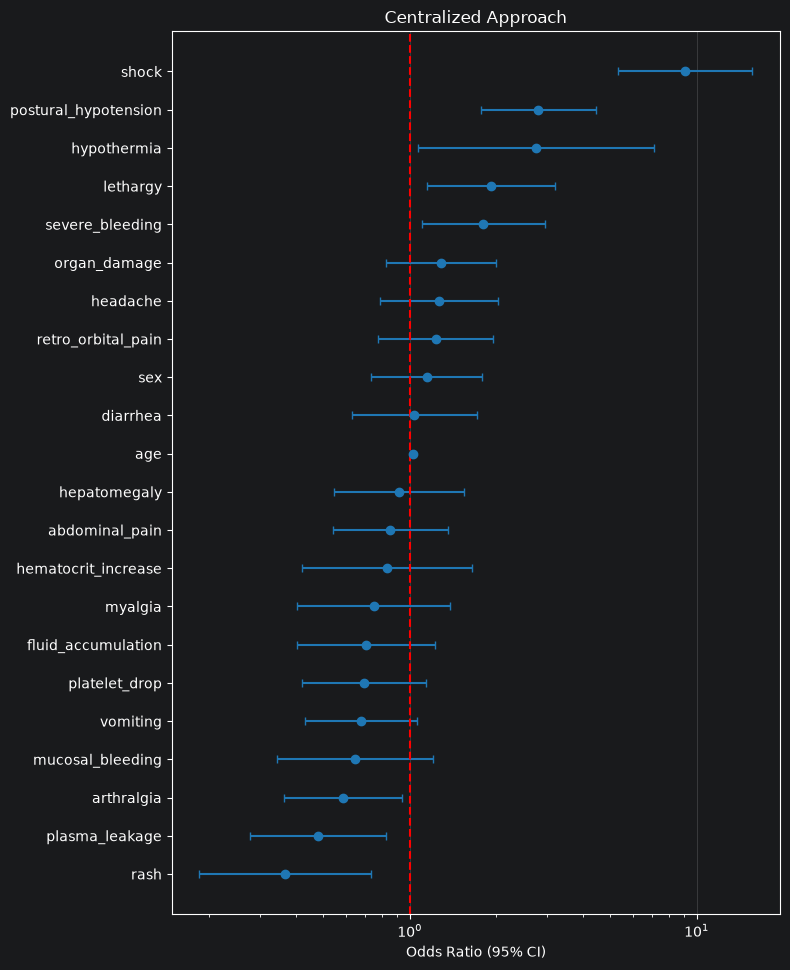

In [16]:
plot_forest(results_centralized, title="Centralized Approach")

### 4.5. Interpreting the results

Reading the forest plot with the criteria described in section 4.2:

- **`shock` shows the strongest association with death.** Its odds ratio (9.13) is the highest, and its confidence interval doesn't include 1. `postural_hypotension` (2.81), `hypothermia` (2.76), `lethargy` (1.92) and `severe_bleeding` (1.81) also have odds ratios above 1 with confidence intervals that don't include 1, so they are associated with higher odds of death as well.
- **Some variables are associated with lower odds of death.** `rash` (0.37), `plasma_leakage` (0.48) and `arthralgia` (0.59) have confidence intervals entirely below 1. This doesn't mean they protect against death. Since every patient here has severe dengue, it means that patients with these variables died less often than the rest of the group. For example, only 20% of patients with `plasma_leakage` were also in shock, compared with 48% of those without it. In addition, `rash` and `arthralgia` are typical of the early phase of the disease, so they likely identify less critical cases.
- **An odds ratio below 1 isn't meaningful on its own if its interval includes 1.** `vomiting` (0.68) and `platelet_drop` (0.69) sit left of 1, but their confidence intervals cross it and their p-values are above 0.05, so there's no evidence of an association with the outcome.
- **`age` has a small but clear association.** Its odds ratio (1.023) looks close to 1 in the plot because it's measured per year of age, yet its interval doesn't include 1. Over several years the effect adds up, so 10 extra years increase the odds of death by about 26%, and 30 extra years roughly double them.
- **`sex` shows no association.** Its odds ratio (1.14) is close to 1, its confidence interval (0.73 to 1.78) includes 1 and its p-value (0.554) is high. This means the data show no evidence of an association, not that one has been ruled out, since with only 97 deaths moderate effects are hard to detect.
- **These are univariate associations, not causal effects.** Each odds ratio is estimated without accounting for the other variables, so part of an association may come from related variables that tend to appear together (e.g. `shock` and `postural_hypotension`).

## 5. Federated Approach

Compute the odds ratios within each institution, then combine them without sharing individual records.

### 5.1. Split the data by institution

Separate the dataset into one subset per institution. Each subset simulates the data a single hospital holds locally: it's the only data that hospital can use to fit its own models, and it never leaves the hospital. What each hospital shares later isn't this data, but the results extracted from its models.

In [17]:
# Simulate each institution's local data: the records only that institution holds
site_data = {site: df.loc[df["institution"] == site] for site in sorted(df["institution"].unique())}

### 5.2. Per-site results

Each institution applies the same `compute_univariate_odds_ratios` function used in the centralized approach, but only on its own data. The resulting table, one row per predictor, is what each institution shares with the central server: model results, never individual records.

In [18]:
outcome = "outcome"

# Predictors: every column except the outcome and institution
predictors = [column for column in df.columns if column not in (outcome, "institution")]

# Dictionary that stores the results for each site
local_results = {}

# Data from each site are evaluated as if each were running its models independently
for site, site_df in site_data.items():
    local_results[site] = compute_univariate_odds_ratios(site_df, outcome=outcome, predictors=predictors)

G:\Trabajo\Isaric\Federated Analytics\Proyectos\Analysis_Dengue\FederatedAnalysis\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
G:\Trabajo\Isaric\Federated Analytics\Proyectos\Analysis_Dengue\FederatedAnalysis\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
G:\Trabajo\Isaric\Federated Analytics\Proyectos\Analysis_Dengue\FederatedAnalysis\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
G:\Trabajo\Isaric\Federated Analytics\Proyectos\Analysis_Dengue\FederatedAnalysis\.venv\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
G:\Trabajo\Isaric\Federated Analytics\Proyectos\Analysis_Dengue\Fede

**About the warnings above**: each `RuntimeWarning: overflow encountered in exp` comes from the model of one predictor at one institution, whose confidence interval couldn't be calculated. The upper limit of the interval is $e^{\beta + 1.96 \cdot SE}$, and when the standard error is huge, that value is too large for the computer to represent, so it's stored as infinite (`inf`). The models still run, but their results aren't meaningful. Section 5.3 shows which models produced these warnings and why.

### 5.3. Unstable per-site results

At some institutions, a Yes/No predictor separates survivors from deaths perfectly, meaning that in one of its two groups nobody died, or nobody survived. This is the same problem found for `petechiae` in section 2.5, but now it only happens within a single institution, because each one has very few deaths (between 17 and 25). When one group has no deaths or no survivors, the model can't estimate how much the odds change, so the coefficient grows without limit and its standard error becomes huge.

First, find the predictors with this problem at each institution, and look at the results they produced:

In [19]:
# Predictors with no deaths or no survivors in one of their groups, at each institution
separated_predictors = find_separated_predictors(site_data, outcome=outcome, predictors=predictors)

# The results these predictors produced at those institutions
display(pd.concat(local_results).loc[separated_predictors.index])

Coefficient        StdErr     OddsRatio  CI95_low  \
H1 hypothermia           -20.167940  14616.219001  1.742509e-09       0.0   
H3 myalgia               -22.323926  12537.265152  2.017632e-10       0.0   
H4 hepatomegaly           21.160776  17730.369793  1.548845e+09       0.0   
H5 shock                  22.141186  18216.429491  4.128524e+09       0.0   
   hypothermia           -19.933546  17730.369914  2.202779e-09       0.0   
   fluid_accumulation    -21.067077  13073.143706  7.090626e-10       0.0   
   hematocrit_increase   -20.998084  16877.355950  7.597099e-10       0.0   

                        CI95_high   p-value  
H1 hypothermia                inf  0.998899  
H3 myalgia                    inf  0.998579  
H4 hepatomegaly               inf  0.999048  
H5 shock                      inf  0.999030  
   hypothermia                inf  0.999103  
   fluid_accumulation         inf  0.998714  
   hematocrit_increase        inf  0.999007

These are the 7 models behind the warnings. None of their values reflects a real association, since the coefficients are around ±20, far larger than any in the centralized results, the standard errors are in the tens of thousands, the upper limit of the confidence interval is infinite, and the p-values are close to 1.

The number of survivors and deaths in each group of these predictors shows why:

In [20]:
# Survivors and deaths among patients without ("No") and with ("Yes") each predictor
display(separated_predictors)

Alive (No)  Dead (No)  Alive (Yes)  Dead (Yes)
site predictor                                                          
H1   hypothermia                  85         21            4           0
H3   myalgia                       0          2           87          15
H4   hepatomegaly                 29         16            0           1
H5   shock                         7          0           26          17
     hypothermia                  32         17            1           0
     fluid_accumulation           28         17            5           0
     hematocrit_increase          30         17            3           0

Every case has a count of 0:

- At H1, none of the patients with `hypothermia` died. The same happens at H5 with `hypothermia`, `fluid_accumulation` and `hematocrit_increase`.
- At H3, the only 2 patients without `myalgia` both died, so no patient without it survived.
- At H4, the only patient with `hepatomegaly` died, so no patient with it survived.
- At H5, `shock` shows the opposite pattern: all 17 deaths had shock, and none of the patients without shock died. Here H5 is actually the institution where the association is strongest, but its model still can't estimate it.

Unlike section 2.5, where these predictors were removed from the whole dataset, here only the affected results are removed, and only at the institution where the problem occurs. Each institution keeps the rest of its results, and each predictor is still combined from the institutions where it could be estimated.

In [21]:
# Remove each unstable result only from the institution where it occurred
for site, predictor in separated_predictors.index:
    local_results[site] = local_results[site].drop(index=predictor)

### 5.4. Aggregated calculations

The central server receives each institution's results and combines them into a single odds ratio per predictor.

This can't be done with a simple average weighted by each institution's number of records, as done for the mean in `02_descriptive_analysis.ipynb`, for two reasons:

`1)` Odds ratios must be combined on the log-odds scale. An odds ratio is asymmetric around 1. For example, odds ratios of 0.5 (half the odds) and 2 (double the odds) are equal and opposite effects, yet their plain average is 1.25. Their coefficients, the logarithms of those odds ratios (-0.69 and 0.69), average to 0, which correctly gives an odds ratio of $e^0 = 1$.

`2)` The precision of each institution's result depends mostly on its number of deaths, not on its number of patients. An odds ratio compares how often patients die with and without the predictor, so its information comes from the deaths. Therefore, an institution with many patients but few deaths gives a less precise result than its size suggests. The institutions show this:

| Institution | Records | Deaths |
|---|---|---|
| H1 | 110 | 21 |
| H2 | 261 | 25 |
| H3 | 104 | 17 |
| H4 | 46 | 17 |
| H5 | 50 | 17 |

Weighting by records, H2 would count about 6 times more than H4, even though it recorded only 25 deaths against H4's 17.

A better weight is the standard error ($SE_i$) each institution already shares, since it measures exactly how precise its result is, so the smaller the error, the more reliable the estimate, and the more it should count.

Each predictor is then combined using each institution's coefficient ($\beta_i$) and standard error ($SE_i$), in three steps:

`1)` Each institution gets a weight equal to one over its squared standard error (the variance of its coefficient), so more precise estimates count more:

$$w_i = \frac{1}{SE_i^2}$$

`2)` The combined coefficient is the weighted average of the institutions' coefficients, and its standard error comes from the sum of the weights:

$$\hat{\beta} = \frac{\sum_{i=1}^{k} w_i \beta_i}{\sum_{i=1}^{k} w_i}, \qquad SE(\hat{\beta}) = \sqrt{\frac{1}{\sum_{i=1}^{k} w_i}}$$

`3)` The combined odds ratio, 95% confidence interval and p-value are derived from these two values, the same way as for a single model:

$$OR = e^{\hat{\beta}}, \qquad CI_{95\%} = e^{\hat{\beta} \pm 1.96 \cdot SE(\hat{\beta})}, \qquad z = \frac{\hat{\beta}}{SE(\hat{\beta})}$$

where $k$ is the number of institutions with a result for that predictor (fewer than 5 for the predictors removed at some institution in section 5.3), and the p-value is obtained from $z$ using the standard normal distribution.

This is still a weighted average, the same idea used in `02_descriptive_analysis.ipynb`, but computed on the log-odds scale and weighted by each estimate's precision instead of by record count. Unlike the counts and sums combined in that notebook, the result is an approximation: it won't necessarily match the centralized odds ratio exactly, as shown in section 6.

In [22]:
# All results shared by the institutions, in one table indexed by (institution, predictor)
shared_results = pd.concat(local_results, names=["site", "predictor"])

# Combine each predictor's results across the institutions that reported it
results_federated = {}
for predictor in predictors:
    # Create a table with the results for each predictor across all sites
    predictor_table = shared_results.xs(predictor, level="predictor")
    # Calculate the federated results using the proposed calculations.
    results_federated[predictor] = pool_odds_ratios(predictor_table)

results_federated = pd.DataFrame.from_dict(results_federated, orient="index")
display(format_odds_ratio_table(results_federated))

,Odds Ratio (95% CI),p-value
shock,"7.258 (4.094, 12.869)",0.0
age,"1.022 (1.012, 1.032)",0.0
postural_hypotension,"2.855 (1.716, 4.749)",0.0
hypothermia,"4.154 (1.233, 14.002)",0.022
lethargy,"1.975 (1.097, 3.554)",0.023
rash,"0.447 (0.216, 0.928)",0.031
vomiting,"0.573 (0.345, 0.95)",0.031
organ_damage,"1.614 (1.005, 2.59)",0.047
severe_bleeding,"1.555 (0.899, 2.689)",0.114
arthralgia,"0.704 (0.413, 1.201)",0.198


## 6. Comparison

Compare the odds ratios obtained with the centralized and federated approaches, predictor by predictor.

### 6.1. Comparison table

Each predictor's odds ratio, 95% confidence interval and p-value, with the centralized results next to the federated ones. `Sites` is the number of institutions combined for each predictor: fewer than 5 where a result was removed in section 5.3.

Every predictor is a Yes/No variable with "No" as the reference category, except `age`, whose odds ratio is per additional year. An asterisk (*) marks p-values below 0.05 (statistically significant, meaning that the association is unlikely to be due to chance alone and its confidence interval doesn't include 1).

In [23]:
display(format_comparison_table(results_centralized, results_federated))

Centralized                    Federated  \
                             OR [95% CI]        p         OR [95% CI]   
shock                 9.13 [5.33; 15.64]  <0.001*  7.26 [4.09; 12.87]   
age                    1.02 [1.01; 1.03]  <0.001*   1.02 [1.01; 1.03]   
postural_hypotension   2.81 [1.77; 4.45]  <0.001*   2.85 [1.72; 4.75]   
rash                   0.37 [0.18; 0.73]   0.004*   0.45 [0.22; 0.93]   
plasma_leakage         0.48 [0.28; 0.83]   0.008*   0.75 [0.41; 1.38]   
lethargy               1.92 [1.15; 3.20]   0.013*   1.98 [1.10; 3.55]   
severe_bleeding        1.81 [1.10; 2.97]   0.020*   1.55 [0.90; 2.69]   
arthralgia             0.59 [0.36; 0.94]   0.027*   0.70 [0.41; 1.20]   
hypothermia            2.76 [1.07; 7.10]   0.036*  4.15 [1.23; 14.00]   
vomiting               0.68 [0.43; 1.06]    0.087   0.57 [0.35; 0.95]   
platelet_drop          0.69 [0.42; 1.14]    0.147   0.76 [0.45; 1.29]   
mucosal_bleeding       0.64 [0.34; 1.20]    0.167   0.83 [0.42; 1.64]   
fluid_accumulation     0.70 [0.40; 1.22]    0.212   1.01 [0.55; 1.86]   
organ_damage           1.29 [0.83; 2.00]    0.264   1.61 [1.01; 2.59]   
headache               1.26 [0.79; 2.03]    0.333   1.21 [0.74; 1.99]   
myalgia                0.75 [0.40; 1.38]    0.354   1.56 [0.76; 3.18]   
retro_orbital_pain     1.23 [0.77; 1.96]    0.382   0.96 [0.58; 1.59]   
abdominal_pain         0.85 [0.54; 1.36]    0.507   0.84 [0.51; 1.39]   
sex                    1.14 [0.73; 1.78]    0.554   1.14 [0.72; 1.82]   
hematocrit_increase    0.83 [0.42; 1.65]    0.603   0.97 [0.46; 2.05]   
hepatomegaly           0.92 [0.54; 1.54]    0.740   0.94 [0.52; 1.70]   
diarrhea               1.04 [0.63; 1.71]    0.890   0.88 [0.51; 1.52]   

                                     
                            p Sites  
shock                 <0.001*     4  
age                   <0.001*     5  
postural_hypotension  <0.001*     5  
rash                   0.031*     5  
plasma_leakage          0.362     5  
lethargy               0.023*     5  
severe_bleeding         0.114     5  
arthralgia              0.198     5  
hypothermia            0.022*     3  
vomiting               0.031*     5  
platelet_drop           0.310     5  
mucosal_bleeding        0.583     5  
fluid_accumulation      0.973     4  
organ_damage           0.047*     5  
headache                0.448     5  
myalgia                 0.224     4  
retro_orbital_pain      0.862     5  
abdominal_pain          0.497     5  
sex                     0.574     5  
hematocrit_increase     0.941     4  
hepatomegaly            0.827     4  
diarrhea                0.653     5

### 6.2. Forest plot

Both approaches on the same forest plot: for each predictor, the centralized result sits just above the federated one, so their odds ratios and confidence intervals can be compared directly.

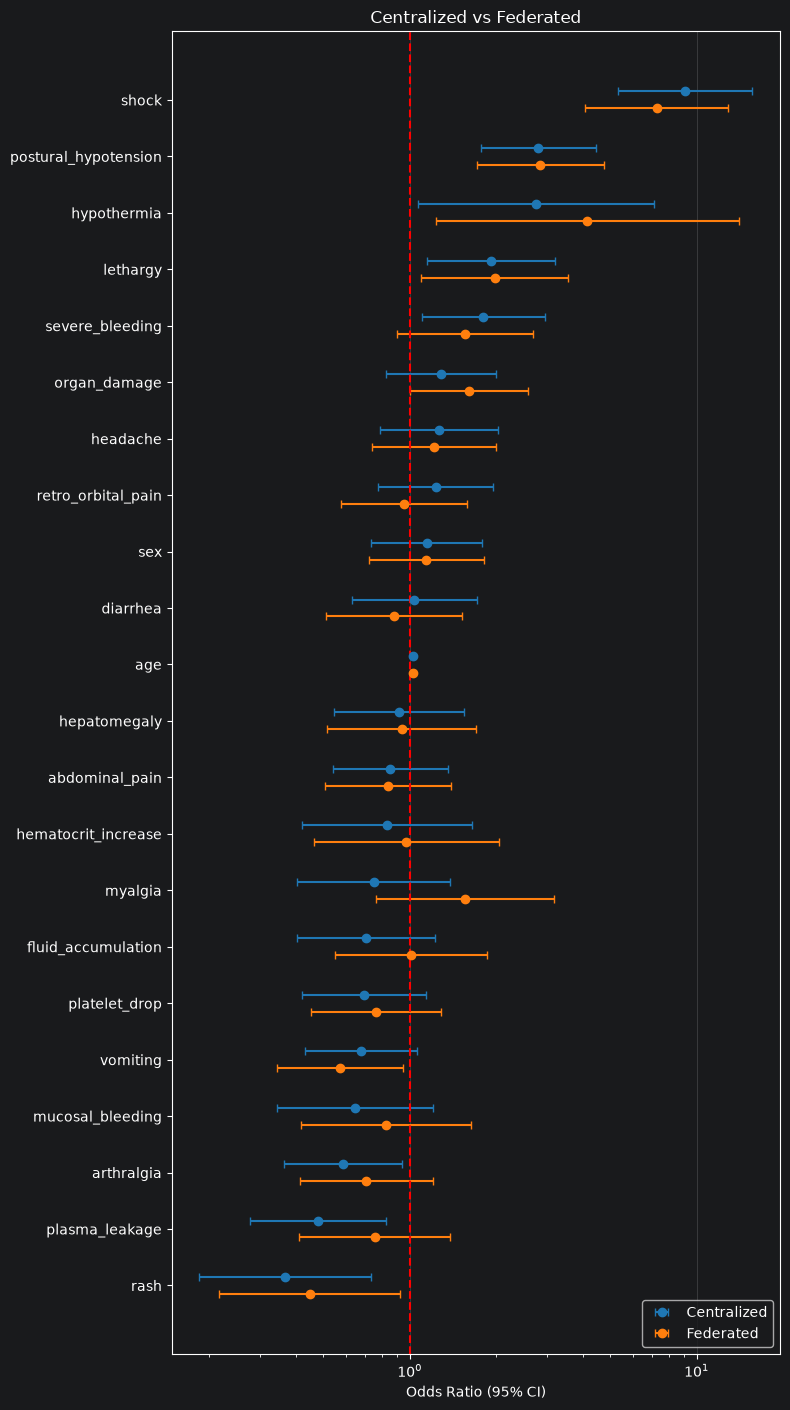

In [24]:
plot_forest(
    results_centralized,
    title="Centralized vs Federated",
    comparison=results_federated,
    labels=("Centralized", "Federated"),
)

### 6.3. Interpreting the results

Reading the table and the forest plot with the same criteria as section 4.5:

- **Overall, both approaches agree.** 17 of the 22 predictors keep the same interpretation, 6 being significant in both and 11 in neither. Only 5 change, since 3 lose significance in the federated approach (`plasma_leakage`, `severe_bleeding`, `arthralgia`) and 2 gain it (`vomiting`, `organ_damage`).
- **The predictors most strongly associated with death are the same.** `shock`, `postural_hypotension`, `hypothermia` and `lethargy` keep odds ratios above 1, with confidence intervals that don't include 1, in both approaches.
- **The largest differences in magnitude appear where fewer institutions were combined.** `shock`, combined from 4 institutions, drops from 9.13 to 7.26, and `hypothermia`, combined from 3, rises from 2.76 to 4.15 with a much wider interval. Both are still above 1. `myalgia`, also combined from 4, moves from 0.75 to 1.56, although its interval includes 1 in both approaches.
- **Some weaker associations lose significance.** `plasma_leakage`, `severe_bleeding` and `arthralgia` were significant in the centralized approach, but their federated intervals include 1. This doesn't show the association is absent, only that the federated results don't provide enough evidence for it.
- **`vomiting` and `organ_damage` show the opposite change.** Their intervals included 1 in the centralized approach, but not in the federated one (`vomiting` 0.57, from 0.35 to 0.95; `organ_damage` 1.61, from 1.01 to 2.59).
- **`age` and `sex` are practically identical.** `age` has an odds ratio of 1.023 in the centralized approach and 1.022 in the federated one, and `sex` has 1.14 in both, so it still shows no association.

Why these differences appear is discussed in section 7.

## 7. Conclusions

- **The federated approach reproduces the main findings of the centralized approach without sharing any individual record.** The predictors most strongly associated with death are the same in both approaches, and most predictors keep the same interpretation. The differences are concentrated in the weaker associations.
- **The differences between the approaches in predictors such as `plasma_leakage` and `organ_damage` can be attributed to differences between institutions, both in how frequent the predictors' values are and in mortality.** For example, H4 recorded 17 deaths among 46 patients, while H2 recorded 25 among 261 (section 5.4). Because the centralized approach evaluates all patients together, the differences between institutions directly influence its results. If a symptom is more common at the institutions with higher mortality, it will appear more strongly associated with death than it actually is within any institution on its own, and the opposite happens if it's more common at the institutions with lower mortality. For example, `plasma_leakage` was recorded in 40% of patients at H2 (10% mortality) but in only 6% at H5 (34% mortality), so its centralized odds ratio (0.48) is lower than its federated one (0.75). In the federated approach, each model only compares patients within the same institution, so those differences don't affect that model's result, since each institution's own mortality is accounted for within its own model.
- **The differences between the federated and centralized results are also related to the number of institutions where each predictor could be estimated.** `shock`, `hypothermia`, `myalgia`, `hepatomegaly`, `fluid_accumulation` and `hematocrit_increase` were combined from 3 or 4 institutions (section 5.3), so their federated results lack the information of the excluded ones. For `shock`, the excluded institution was the one where the association was strongest, which contributes to its lower federated odds ratio.
- **The results of the federated approach are especially affected by the low number of deaths recorded at each institution.** There are 97 deaths among 571 patients, and only between 17 and 25 per institution. With so few deaths, each institution's estimates are imprecise, so the federated odds ratios are an approximation. Unlike the means combined in `02_descriptive_analysis.ipynb`, they can't be expected to match the centralized ones exactly.
- **Univariate modelling isn't a source of difference between the approaches.** Both use it, because there are too few deaths for a multivariate model (see section 3). Comparing both approaches with a multivariate model could complement this analysis.
- **Each institution's results should be reviewed before combining them, since how to combine them depends on whether they could be estimated and how similar they are.** Section 5.3 showed models that couldn't be estimated at some institutions. The combination in section 5.4 assumes the association is the same at every institution, treating the differences between their results as due to chance alone. For some predictors, those results differ more than chance would explain; in that case, a combination method that accounts for the variation between institutions is more appropriate, and gives wider confidence intervals.